# 多通道去耦合測試

此 notebook 專門用於處理**紫色/洋紅色干擾**（紅色+藍色混合）

## 適用情況
- 影像中出現紫色或洋紅色背景螢光
- 自體螢光同時影響紅色和藍色通道
- 需要同時校正紅色和藍色對綠色的干擾

## 校正公式
```
Green_corrected = Green_original - α × Red - β × Blue
```

其中：
- α (alpha): 紅色去耦合係數
- β (beta): 藍色去耦合係數

## 1. 導入必要的套件

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from itertools import product

# 添加專案路徑
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# 導入處理模組
from preprocessing.channel_decoupling import ChannelDecoupler
from preprocessing.config import ChannelDecouplingConfig
from preprocessing.image_loader import ImageLoader

# 設定 matplotlib 中文顯示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件導入完成")

✓ 套件導入完成


## 2. 載入測試影像

In [10]:
# 設定影像路徑
IMAGE_PATH = "/Users/ponywen/projects/ienf_q/data/Original/S163-2_a.tif"  # 請修改此路徑
LABLE_PATH = IMAGE_PATH.replace("Original", "Label")
# 使用 ImageLoader 載入影像
loader = ImageLoader()
image_data = loader.load(IMAGE_PATH)

from PIL import Image
label_image = Image.open(LABLE_PATH).convert("L")
label_data = np.array(label_image)

print(f"影像尺寸: {image_data.shape}")
print(f"標籤尺寸: {label_data.shape}")
print(f"數據類型: {image_data.dtype}")
print(f"數值範圍: [{image_data.min()}, {image_data.max()}]")

✓ 載入圖像: S163-2_a.tif
  - 尺寸: (1028, 4713, 3)
  - 類型: uint8
  - 範圍: [0, 255]
影像尺寸: (1028, 4713, 3)
標籤尺寸: (1028, 4713)
數據類型: uint8
數值範圍: [0, 255]


## 3. 分離 RGB 三個通道

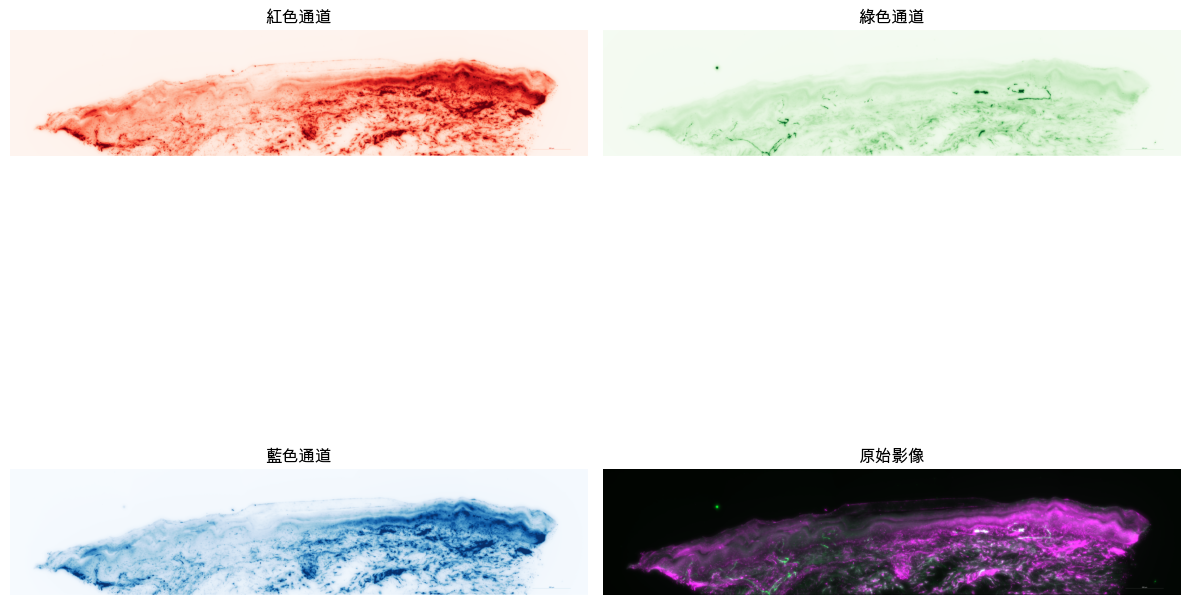


通道統計:
紅色 - 範圍: [0, 254], 平均: 50.6
綠色 - 範圍: [0, 254], 平均: 30.0
藍色 - 範圍: [0, 255], 平均: 54.9


In [3]:
# 分離通道
if len(image_data.shape) == 3 and image_data.shape[2] >= 3:
    red_channel = image_data[:, :, 0]
    green_channel = image_data[:, :, 1]
    blue_channel = image_data[:, :, 2]
else:
    raise ValueError(f"需要 RGB 影像（至少 3 個通道），收到 {image_data.shape}")

# 顯示所有通道
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# 紅色通道
axes[0, 0].imshow(red_channel, cmap='Reds')
axes[0, 0].set_title('紅色通道')
axes[0, 0].axis('off')

# 綠色通道
axes[0, 1].imshow(green_channel, cmap='Greens')
axes[0, 1].set_title('綠色通道')
axes[0, 1].axis('off')

# 藍色通道
axes[1, 0].imshow(blue_channel, cmap='Blues')
axes[1, 0].set_title('藍色通道')
axes[1, 0].axis('off')

# 原始影像
axes[1, 1].imshow(image_data)
axes[1, 1].set_title('原始影像')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n通道統計:")
print(f"紅色 - 範圍: [{red_channel.min()}, {red_channel.max()}], 平均: {red_channel.mean():.1f}")
print(f"綠色 - 範圍: [{green_channel.min()}, {green_channel.max()}], 平均: {green_channel.mean():.1f}")
print(f"藍色 - 範圍: [{blue_channel.min()}, {blue_channel.max()}], 平均: {blue_channel.mean():.1f}")

## 4. 分析紫色成分

紫色 = 紅色 + 藍色。讓我們看看紅色和藍色的組合

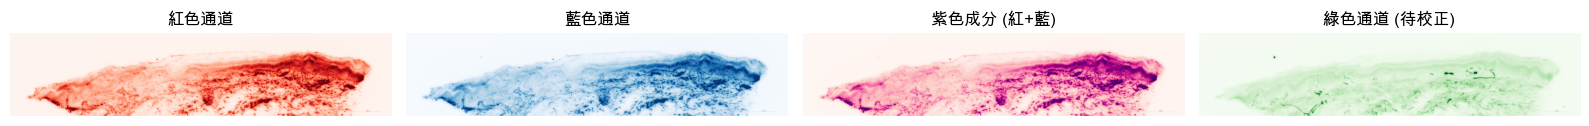

In [4]:
# 創建紫色通道（紅+藍）
purple_channel = (red_channel.astype(float) + blue_channel.astype(float)) / 2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(red_channel, cmap='Reds')
axes[0].set_title('紅色通道')
axes[0].axis('off')

axes[1].imshow(blue_channel, cmap='Blues')
axes[1].set_title('藍色通道')
axes[1].axis('off')

axes[2].imshow(purple_channel, cmap='RdPu')
axes[2].set_title('紫色成分 (紅+藍)')
axes[2].axis('off')

axes[3].imshow(green_channel, cmap='Greens')
axes[3].set_title('綠色通道 (待校正)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## 5. 比較：僅紅色校正 vs 多通道校正

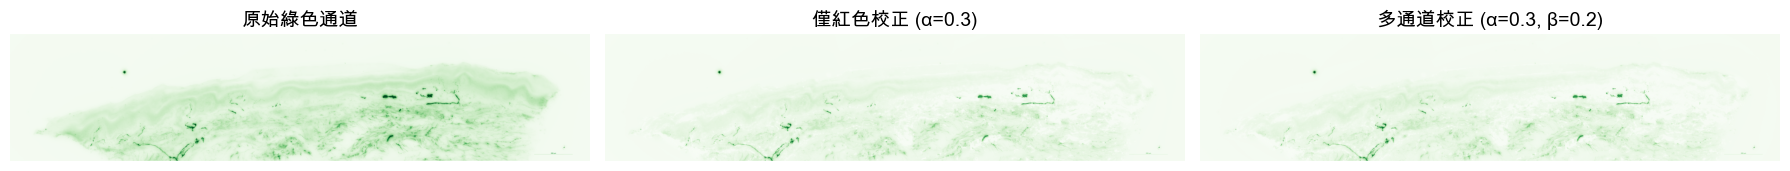

統計比較:
原始   - 平均: 30.0, 標準差: 26.4
僅紅色 - 平均: 14.7, 標準差: 15.5
多通道 - 平均: 14.0, 標準差: 15.0


In [6]:
# 方法 1: 僅紅色校正（傳統方法）
config_red_only = ChannelDecouplingConfig(
    alpha=0.3,
    use_blue_channel=False
)
decoupler_red = ChannelDecoupler(config_red_only)
corrected_red_only = decoupler_red.process(green_channel, red_channel)

# 方法 2: 多通道校正（紅+藍）
config_multiband = ChannelDecouplingConfig(
    alpha=0.15,  # 紅色係數
    beta=0.15,   # 藍色係數
    use_blue_channel=True
)
decoupler_multi = ChannelDecoupler(config_multiband)
corrected_multiband = decoupler_multi.process(green_channel, red_channel, blue_channel)

# 顯示比較
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(green_channel, cmap='Greens')
axes[0].set_title('原始綠色通道', fontsize=14)
axes[0].axis('off')

axes[1].imshow(corrected_red_only, cmap='Greens')
axes[1].set_title('僅紅色校正 (α=0.3)', fontsize=14)
axes[1].axis('off')

axes[2].imshow(corrected_multiband, cmap='Greens')
axes[2].set_title('多通道校正 (α=0.3, β=0.2)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("統計比較:")
print(f"原始   - 平均: {green_channel.mean():.1f}, 標準差: {green_channel.std():.1f}")
print(f"僅紅色 - 平均: {corrected_red_only.mean():.1f}, 標準差: {corrected_red_only.std():.1f}")
print(f"多通道 - 平均: {corrected_multiband.mean():.1f}, 標準差: {corrected_multiband.std():.1f}")

## 6. 網格搜索最佳參數

測試不同的 α 和 β 組合，找出最佳參數

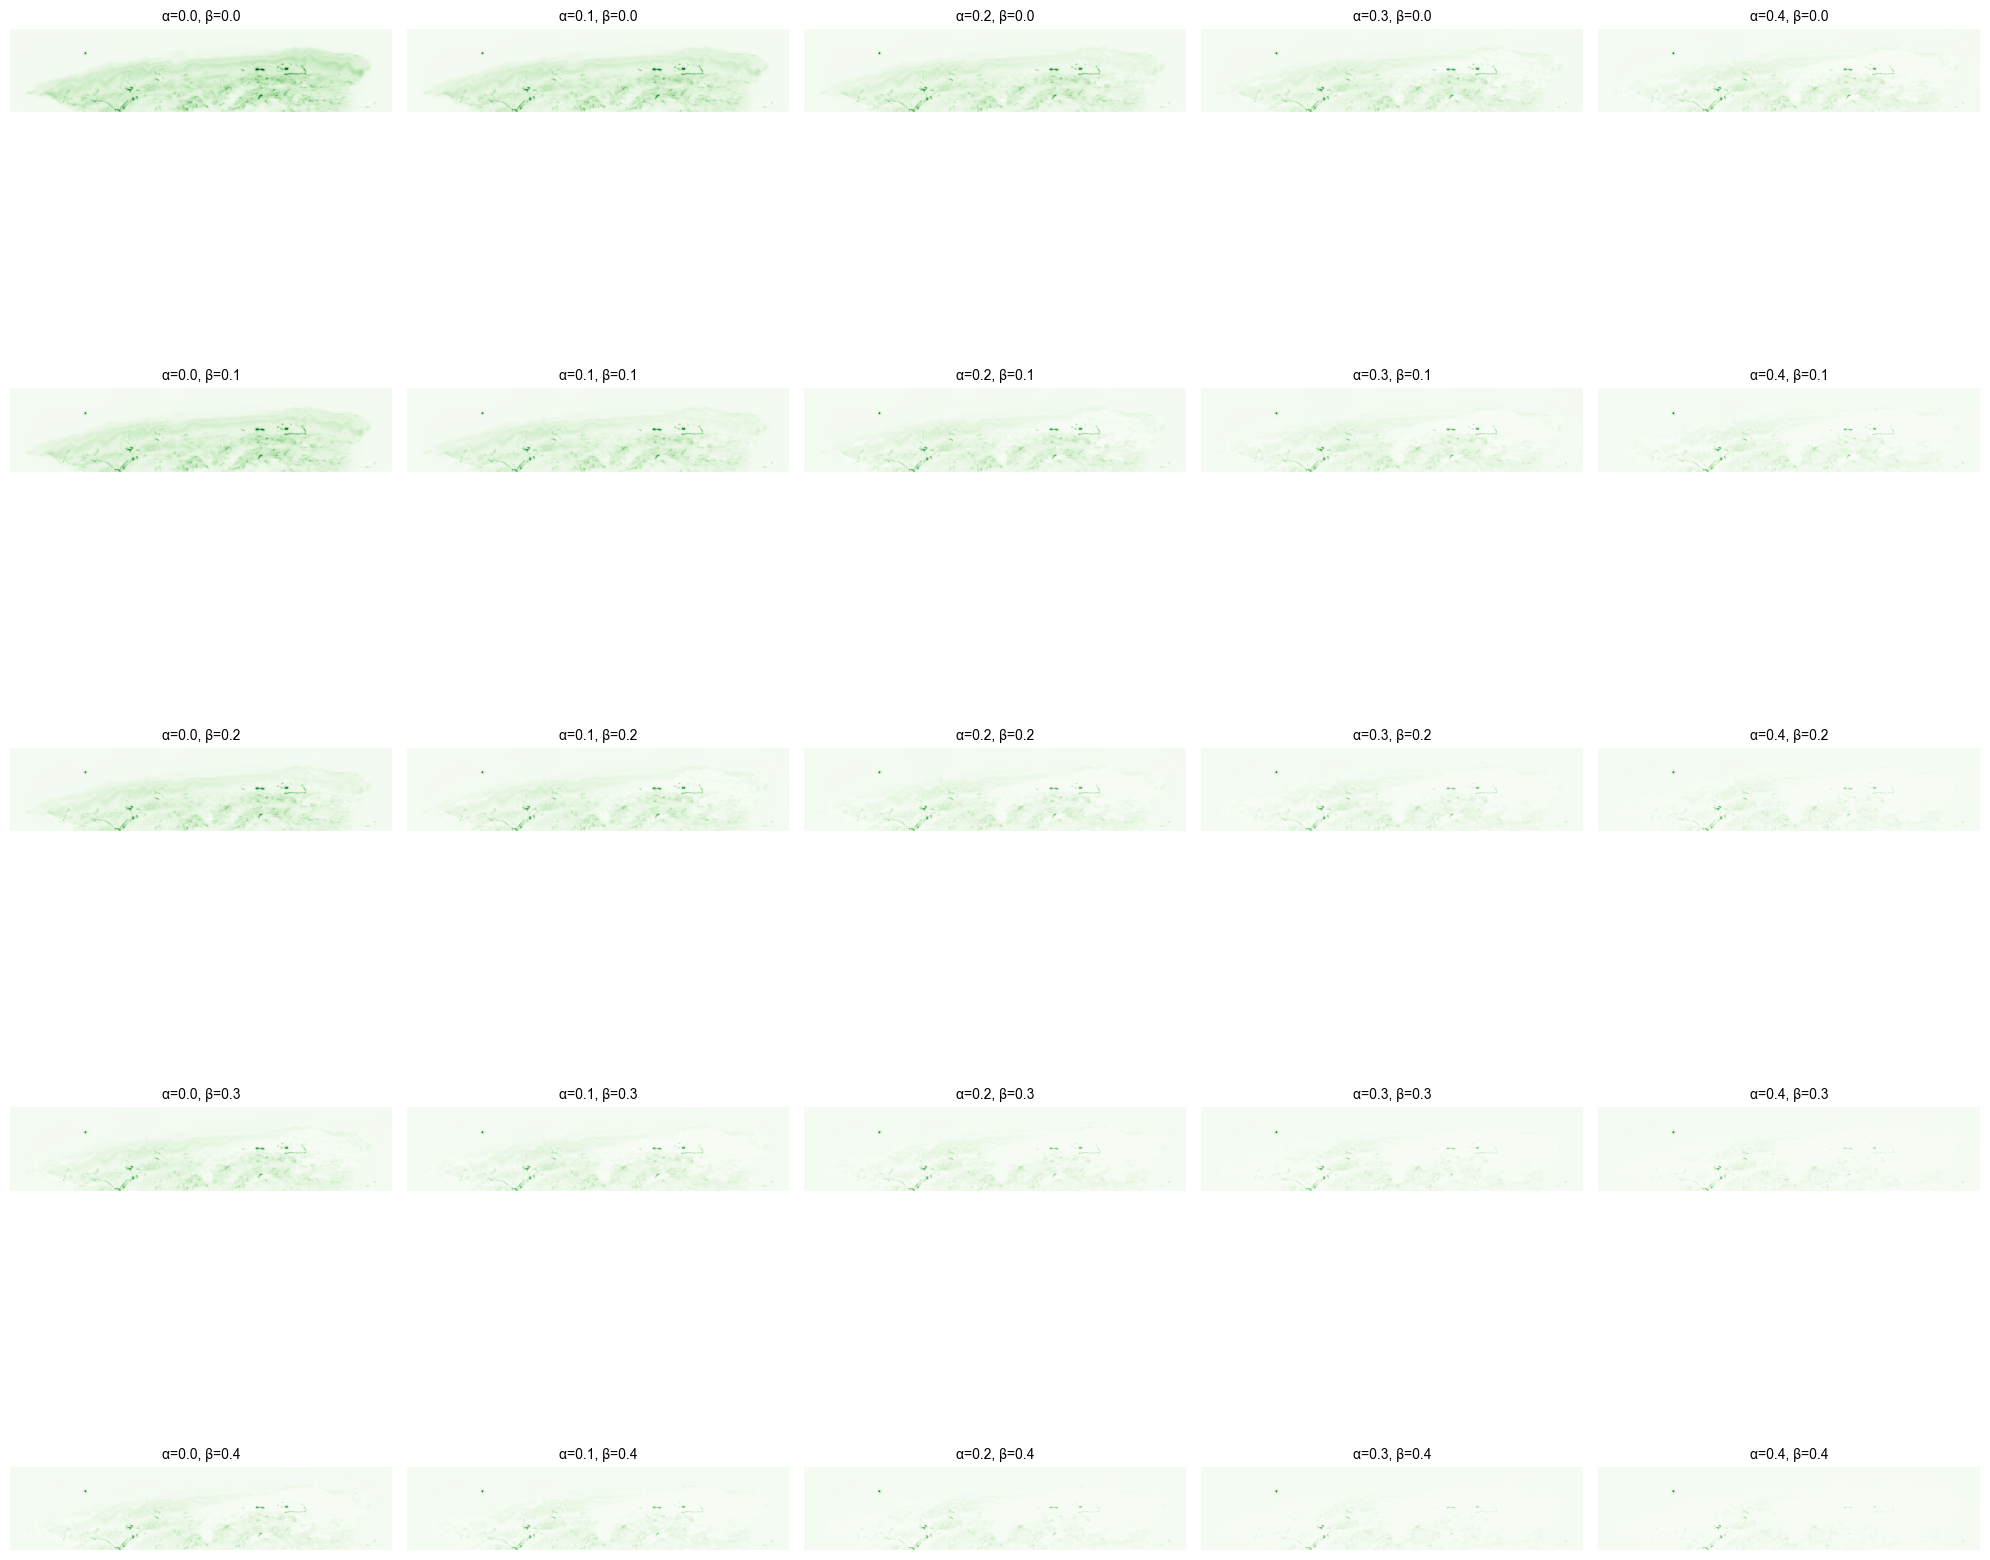

請觀察上面的網格，選擇視覺效果最好的 α 和 β 組合


In [7]:
# 定義參數範圍
alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4]
beta_values = [0.0, 0.1, 0.2, 0.3, 0.4]

# 創建子圖
fig, axes = plt.subplots(len(beta_values), len(alpha_values), figsize=(20, 20))

for i, beta in enumerate(beta_values):
    for j, alpha in enumerate(alpha_values):
        # 配置
        config = ChannelDecouplingConfig(
            alpha=alpha,
            beta=beta,
            use_blue_channel=(beta > 0)  # 只有 beta > 0 才使用藍色通道
        )
        
        # 應用校正
        decoupler = ChannelDecoupler(config)
        if beta > 0:
            corrected = decoupler.process(green_channel, red_channel, blue_channel)
        else:
            corrected = decoupler.process(green_channel, red_channel)
        
        # 顯示
        axes[i, j].imshow(corrected, cmap='Greens')
        axes[i, j].set_title(f'α={alpha}, β={beta}', fontsize=10)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

print("請觀察上面的網格，選擇視覺效果最好的 α 和 β 組合")

## 7. 使用最佳參數進行詳細分析

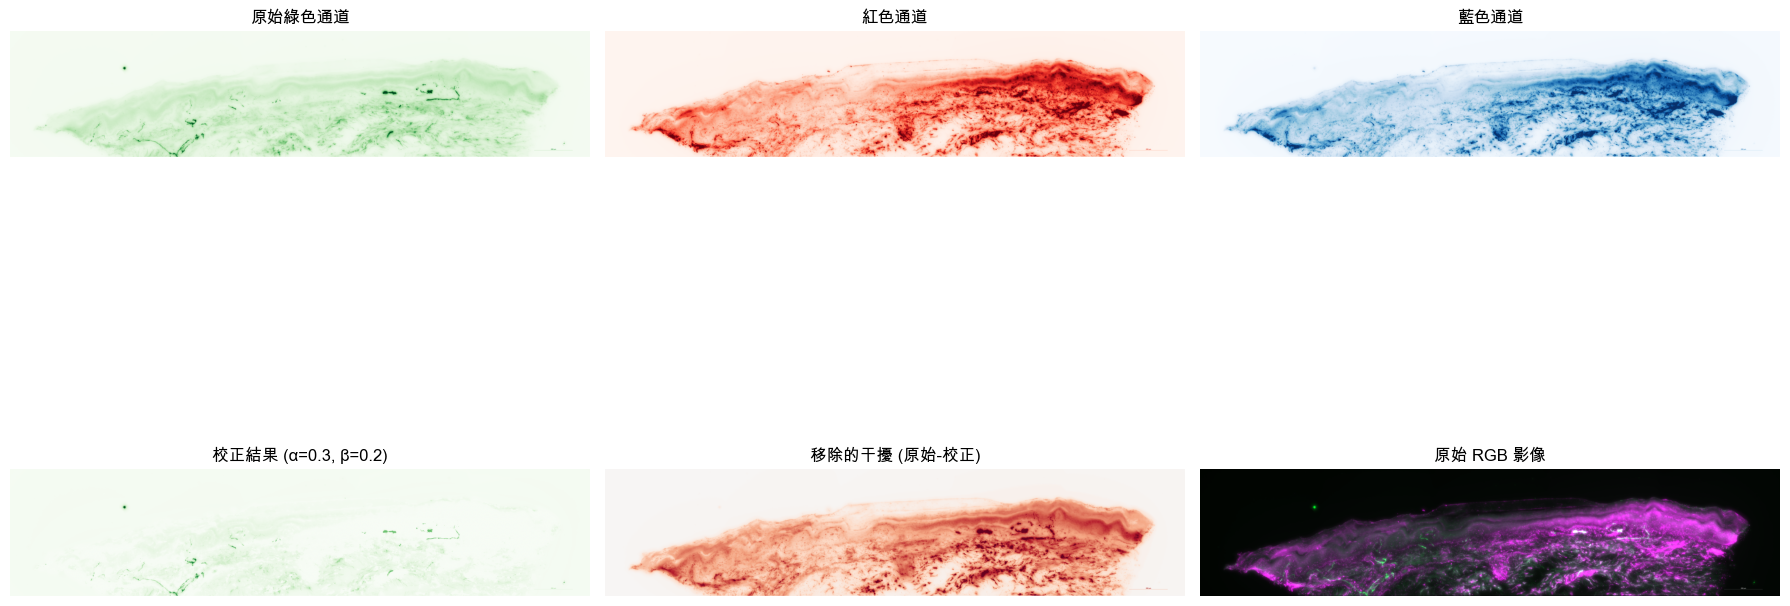


校正統計:
移除的平均強度: 22.47
移除的標準差: 22.81

校正效果: 平均移除了 74.9% 的干擾信號


In [8]:
# 根據上面的網格搜索，設定最佳參數
BEST_ALPHA = 0.3  # 請修改為最佳值
BEST_BETA = 0.2   # 請修改為最佳值

config_best = ChannelDecouplingConfig(
    alpha=BEST_ALPHA,
    beta=BEST_BETA,
    use_blue_channel=True
)

decoupler_best = ChannelDecoupler(config_best)
corrected_best = decoupler_best.process(green_channel, red_channel, blue_channel)

# 計算各種差異
diff_original = green_channel.astype(float) - corrected_best.astype(float)

# 詳細視覺化
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 第一行：通道
axes[0, 0].imshow(green_channel, cmap='Greens')
axes[0, 0].set_title('原始綠色通道', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(red_channel, cmap='Reds')
axes[0, 1].set_title('紅色通道', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(blue_channel, cmap='Blues')
axes[0, 2].set_title('藍色通道', fontsize=12)
axes[0, 2].axis('off')

# 第二行：結果
axes[1, 0].imshow(corrected_best, cmap='Greens')
axes[1, 0].set_title(f'校正結果 (α={BEST_ALPHA}, β={BEST_BETA})', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(diff_original, cmap='RdBu_r', vmin=-100, vmax=100)
axes[1, 1].set_title('移除的干擾 (原始-校正)', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(image_data)
axes[1, 2].set_title('原始 RGB 影像', fontsize=12)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n校正統計:")
print(f"移除的平均強度: {diff_original.mean():.2f}")
print(f"移除的標準差: {diff_original.std():.2f}")
print(f"\n校正效果: 平均移除了 {(diff_original.mean()/green_channel.mean()*100):.1f}% 的干擾信號")

## 8. 局部區域詳細比較

In [ ]:
# 選擇感興趣區域
y_start, y_end = 200, 400
x_start, x_end = 300, 500

# 僅紅色校正（對比）
config_red_only = ChannelDecouplingConfig(alpha=BEST_ALPHA, use_blue_channel=False)
corrected_red_only = ChannelDecoupler(config_red_only).process(green_channel, red_channel)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 第一行：完整影像
axes[0, 0].imshow(green_channel, cmap='Greens')
axes[0, 0].set_title('原始')
axes[0, 0].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start,
                                   fill=False, edgecolor='red', linewidth=2))
axes[0, 0].axis('off')

axes[0, 1].imshow(corrected_red_only, cmap='Greens')
axes[0, 1].set_title('僅紅色校正')
axes[0, 1].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start,
                                   fill=False, edgecolor='red', linewidth=2))
axes[0, 1].axis('off')

axes[0, 2].imshow(corrected_best, cmap='Greens')
axes[0, 2].set_title('多通道校正')
axes[0, 2].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start,
                                   fill=False, edgecolor='red', linewidth=2))
axes[0, 2].axis('off')

diff_methods = corrected_red_only.astype(float) - corrected_best.astype(float)
axes[0, 3].imshow(diff_methods, cmap='RdBu_r')
axes[0, 3].set_title('方法差異')
axes[0, 3].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start,
                                   fill=False, edgecolor='red', linewidth=2))
axes[0, 3].axis('off')

# 第二行：局部放大
axes[1, 0].imshow(green_channel[y_start:y_end, x_start:x_end], cmap='Greens')
axes[1, 0].set_title('原始 (放大)')
axes[1, 0].axis('off')

axes[1, 1].imshow(corrected_red_only[y_start:y_end, x_start:x_end], cmap='Greens')
axes[1, 1].set_title('僅紅色 (放大)')
axes[1, 1].axis('off')

axes[1, 2].imshow(corrected_best[y_start:y_end, x_start:x_end], cmap='Greens')
axes[1, 2].set_title('多通道 (放大)')
axes[1, 2].axis('off')

axes[1, 3].imshow(diff_methods[y_start:y_end, x_start:x_end], cmap='RdBu_r')
axes[1, 3].set_title('差異 (放大)')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

## 9. 直方圖分析

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 原始
axes[0].hist(green_channel.flatten(), bins=100, color='green', alpha=0.7, label='原始')
axes[0].set_title('原始綠色通道直方圖')
axes[0].set_xlabel('像素值')
axes[0].set_ylabel('頻率')
axes[0].grid(True, alpha=0.3)

# 僅紅色校正
axes[1].hist(corrected_red_only.flatten(), bins=100, color='darkgreen', alpha=0.7)
axes[1].set_title('僅紅色校正直方圖')
axes[1].set_xlabel('像素值')
axes[1].set_ylabel('頻率')
axes[1].grid(True, alpha=0.3)

# 多通道校正
axes[2].hist(corrected_best.flatten(), bins=100, color='seagreen', alpha=0.7)
axes[2].set_title('多通道校正直方圖')
axes[2].set_xlabel('像素值')
axes[2].set_ylabel('頻率')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 保存結果

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# 保存結果
Image.fromarray(corrected_red_only).save(
    output_dir / f"corrected_red_only_alpha{BEST_ALPHA}_{timestamp}.png"
)

Image.fromarray(corrected_best).save(
    output_dir / f"corrected_multiband_a{BEST_ALPHA}_b{BEST_BETA}_{timestamp}.png"
)

# 保存差異圖
diff_normalized = ((diff_original - diff_original.min()) / 
                   (diff_original.max() - diff_original.min()) * 255).astype(np.uint8)
Image.fromarray(diff_normalized).save(
    output_dir / f"removed_interference_{timestamp}.png"
)

print(f"✓ 結果已保存至 {output_dir}")
print(f"  - 僅紅色校正: corrected_red_only_alpha{BEST_ALPHA}_{timestamp}.png")
print(f"  - 多通道校正: corrected_multiband_a{BEST_ALPHA}_b{BEST_BETA}_{timestamp}.png")
print(f"  - 移除的干擾: removed_interference_{timestamp}.png")

## 11. 參數調整指南

### 何時使用多通道校正？

✅ **應該使用多通道校正的情況：**
- 影像中有明顯的紫色/洋紅色背景
- 紅色和藍色通道都很亮
- 僅紅色校正後仍有殘留干擾
- 自體螢光呈現紫色

❌ **不需要多通道校正的情況：**
- 干擾主要來自紅色通道
- 藍色通道很暗或沒有信號
- 僅紅色校正已經足夠

### 參數調整建議

**α (alpha) - 紅色去耦合係數:**
- 起始值: 0.2 - 0.3
- 如果紅色干擾明顯: 增加到 0.4 - 0.5
- 如果過度校正: 減少到 0.1 - 0.2

**β (beta) - 藍色去耦合係數:**
- 起始值: 0.1 - 0.2
- 通常比 α 小，因為藍色干擾較少
- 如果紫色很明顯: 可以增加到 0.3 - 0.4
- 如果藍色通道很暗: 保持在 0.0 - 0.1

### 調整策略

1. **先調整 α（紅色）**
   - 設定 β = 0
   - 找到最佳的 α 值

2. **再調整 β（藍色）**
   - 固定上一步的 α
   - 逐步增加 β，觀察效果

3. **微調兩者**
   - 使用網格搜索找到最佳組合
   - 觀察神經纖維的清晰度
   - 確保不會過度校正（信號變暗）